In [ ]:
import numpy as np
from scipy import stats
import pandas as pd
!pip install scikit_posthocs

pd.options.display.float_format = '{:,.4f}'.format

# Testes de Hipóteses

H0: hipótese nula

H1: hipótese alternativa

Possíveis configurações:

1.   H0: média == x, H1 média != x
2.   H0: média <= x, H1 média > x
3. H0: média >= x, H1 média < x




**Para checar para usar um teste paramétrica ou não-paramétricos, checar os seguintes requisitos:**

- Observações são independentes e identicamente distribuídas
- Distribuídas normalemtne
- Variância Igual

**Como checar se é Pareado ou não-pareado?**

Se forem pareados, os dados das 2 comparações são feitos pela mesmo pessoa ou experimento.

Como escolher o teste de Hipótese?

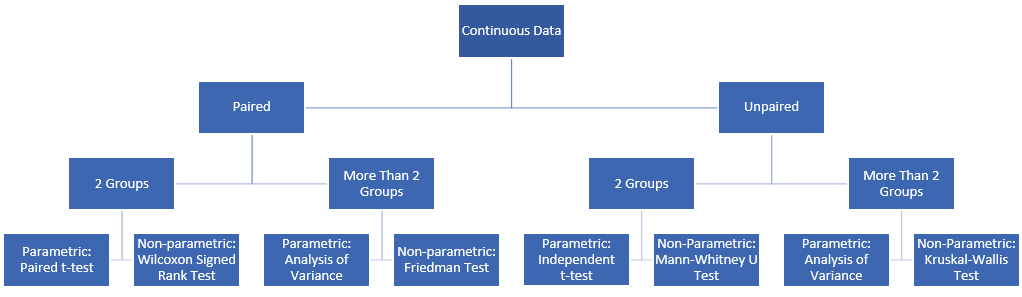

Lista dos testes:

- [Paired t-test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html#scipy.stats.ttest_rel)
- [Wilcoxon Signed Rank Test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html#scipy.stats.wilcoxon)
-  [Analysis of Variance (ANOVA)](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html#scipy.stats.f_oneway)
- [Friedman Test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.friedmanchisquare.html#scipy.stats.friedmanchisquare)
- [Independent t-test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html#scipy.stats.ttest_ind)
- [Mann-Whitey U test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html#scipy.stats.mannwhitneyu)
- [Kruskal-Walls test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html)

## Passo 1: Verificar se a distribuição é paramétrica (Normal)

Fazer um teste de normalidade. Aqui estamos usando o teste de D’Agostino e Pearson com significância de 5%.

In [ ]:
def checar_se_eh_parametrica(dados):
  test_stat, p_value = stats.normaltest(dados)
  print("p value:%.4f" % p_value)
  if p_value >= 0.05:
      print("É paramétrico")
  else:
    print("Não é paramétrico")

Problema 0 - Assistindo mais TV

Um sociólogo afirma que crianças entre 6 e 17 anos passavam mais tempo assistindo TV em 1981 do que hoje.

EM $\alpha = 0.01$ podemos confirmar?

### Definição da hipótese:

- H0: média_hoje >= media_1984
- H1: média_hoje < media_1984

In [ ]:
horas_em_1981 = [2.0, 2.5, 2.3, 2.1, 1.6, 2.6, 2.1, 2.1, 2.4, 2.1, 2.1, 1.5, 1.7, 2.1, 2.3, 2.5, 3.3, 2.2, 2.9, 1.5, 1.9, 2.4, 2.2, 1.2, 3.0, 1.0, 1.9, 2.2]
horas_hoje = [2.9, 1.8, 0.9, 1.6, 2.0, 1.7, 2.5, 1.1, 1.6, 2.0, 1.4, 1.7, 1.7, 1.9, 1.6, 1.7, 1.2, 2.0, 2.6, 1.6, 1.5, 2.5, 1.6, 2.1, 1.7, 1.8, 1.1, 1.4, 2.3]

In [ ]:
checar_se_eh_parametrica(horas_em_1981)

p value:0.6703
É paramétrico


In [ ]:
checar_se_eh_parametrica(horas_hoje)

p value:0.4257
É paramétrico


In [ ]:
ttest,p_value = stats.ttest_ind(horas_em_1981, horas_hoje, alternative="less")
print("p-valor:%.8f" % p_value)
if p_value >= 0.05:
  print("Falhou em rejeitar a hipótese nula - Aceitar H0")
else:
  print("Rejeitou a hipótese nula")

p-valor:0.99608358
Falhou em rejeitar a hipótese nula - Aceitar H0


# Problema 1 - Notas

O professor do SENAC de Ciência de Dados gostaria de checar se as notas da disciplina teve diferenças quando as aulas foram remotas ou presenciais. Assumindo que são turmas diferentes, será que os alunos do remoto tiveram notas piores?

### Definição da hipótese:

- H0: nota_presencial <= nota_remoto
- H1: nota_presencial > nota_remoto

## Premissas

H₀: A distribuição é normal

H₁:  A distribuição não é normal

α = 0.05 , se p-valor > 0.05 , os dados são distribuídos normalmente.

In [ ]:
presencial = np.array([94. , 84.9, 82.6, 69.5, 80.1, 79.6, 81.4, 77.8, 81.7, 78.8, 73.2,
       87.9, 87.9, 93.5, 82.3, 79.3, 78.3, 71.6, 88.6, 74.6, 74.1, 80.6])
remoto = np.array([77.1, 71.7, 91. , 72.2, 74.8, 85.1, 67.6, 69.9, 75.3, 71.7, 65.7, 72.6, 71.5, 78.2])

checar_se_eh_parametrica(presencial)
checar_se_eh_parametrica(remoto)

p value:0.7719
É paramétrico
p value:0.0345
Não é paramétrico


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
## Escolhendo o teste apropriado:

ttest,p_value = stats.mannwhitneyu(presencial, remoto)
print("p-valor:%.8f" % p_value)
if p_value >= 0.05:
  print("Falhou em rejeitar a hipótese nula - Aceitar H0")
else:
  print("Rejeitou a hipótese nula")

p-valor:0.00552305
Rejeitou a hipótese nula


# Problema 2 - Metodologias de pesquisa

Um pesquisador do SENAC fez uma metodologia C e quer comparar a performance com metodologias já consolidados na área A e B com 8 experimentos conhecidos.

### Definição da hipótese:

- H0: média_a == média_b == média_c
- H1: Alguma é diferente

In [ ]:
metodologia_a = np.array([89.9, 89.9, 88.6, 88.7, 89.6, 89.7, 89.2, 89.3])
metodologia_b = np.array([90.0, 90.1, 88.8, 88.9, 89.9, 90.0, 89.0, 89.2])
metodologia_c = np.array([91.5, 90.7, 90.3, 90.4, 90.2, 90.3, 90.2, 90.3])

In [ ]:
checar_se_eh_parametrica(metodologia_a)
checar_se_eh_parametrica(metodologia_b)
checar_se_eh_parametrica(metodologia_c)

p value:0.5454

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  res = hypotest_fun_out(*samples, **kwds)



É paramétrico
p value:0.0633
É paramétrico
p value:0.0009
Não é paramétrico


Como um dos modelos não é paramétrico, iremos usar o teste de Friedman

In [ ]:
test_stat,p_value = stats.friedmanchisquare(metodologia_a,metodologia_b, metodologia_c)
print("p-valor:%.8f" % p_value)
if p_value >= 0.05:
  print("Falhou em rejeitar a hipótese nula - Aceitar H0")
else:
  print("Rejeitou a hipótese nula")

p value:0.0015
Rejeitar a hipótese nula


Podemos concluir que um dos 3 experimentos não perfomam igual.
